In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

from statsmodels.stats.proportion import proportions_ztest

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("ggplot")
%matplotlib inline

In [2]:
#importing files from folder

In [3]:
ab_df = pd.read_csv(r"C:\Users\mahen\OneDrive\Desktop\Ab testing\ab_data.csv")
country_df = pd.read_csv(r"C:\Users\mahen\OneDrive\Desktop\Ab testing\countries.csv")

In [4]:
#understand the data

In [5]:
ab_df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [6]:
country_df.head()

,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


In [7]:
#checking the shape

In [8]:
print("AB Data shape:",ab_df.shape)
print("Country data shape:", country_df.shape)

AB Data shape: (294480, 5)
Country data shape: (290586, 2)


# checkdata types

In [9]:
ab_df.info()
country_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294480 entries, 0 to 294479
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294480 non-null  int64 
 1   timestamp     294480 non-null  object
 2   group         294480 non-null  object
 3   landing_page  294480 non-null  object
 4   converted     294480 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290586 entries, 0 to 290585
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   user_id  290586 non-null  int64 
 1   country  290586 non-null  object
dtypes: int64(1), object(1)
memory usage: 4.4+ MB


## check missing values

In [10]:
ab_df.isnull().sum()
country_df.isnull().sum()

user_id    0
country    0
dtype: int64

## merging both dataset



In [11]:
df = pd.merge(ab_df,country_df,on='user_id' , how = 'left')

In [12]:
df.head()

,user_id,timestamp,group,landing_page,converted,country
0,851104,11:48.6,control,old_page,0,US
1,804228,01:45.2,control,old_page,0,US
2,661590,55:06.2,treatment,new_page,0,US
3,853541,28:03.1,treatment,new_page,0,US
4,864975,52:26.2,control,old_page,1,US


In [13]:
df.shape

(294482, 6)

# save the merged data

In [14]:
df.to_csv("merged_ab_data.csv",index = False)

# Business Understading

In [15]:
df_clean = df.copy()

In [16]:
df_clean.shape[0]

294482

In [17]:
df_clean.shape[1]

6

In [18]:
df_clean.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
country         0
dtype: int64

In [19]:
df_clean.duplicated().sum()

np.int64(2)

 # Check Duplicate User IDs

In [20]:
df_clean['user_id'].duplicated().sum()

np.int64(3897)

In [21]:
df_clean[df_clean['user_id'].duplicated(keep=False)].sort_values('user_id')

,user_id,timestamp,group,landing_page,converted,country
213114,630052,25:54.1,treatment,old_page,1,US
230259,630052,16:05.2,treatment,new_page,0,US
251763,630126,16:00.3,treatment,new_page,0,US
22513,630126,35:54.8,treatment,old_page,0,US
11792,630137,59:22.1,control,new_page,0,US
...,...,...,...,...,...,...
99479,945703,39:31.3,control,old_page,0,US
186960,945797,23:21.8,control,old_page,0,UK
40370,945797,04:49.4,control,new_page,1,UK
165143,945971,09:18.4,control,old_page,0,US


# check group distribution

In [22]:
df_clean['group'].value_counts()

group
treatment    147280
control      147202
Name: count, dtype: int64

In [23]:
df_clean['landing_page'].value_counts()

landing_page
new_page    147243
old_page    147239
Name: count, dtype: int64

In [24]:
df_clean['converted'].value_counts(normalize = True) * 100

converted
0    88.034243
1    11.965757
Name: proportion, dtype: float64

In [25]:
pd.crosstab(df_clean['group'],df_clean['landing_page'])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145315,1965


# count invalid assignments

In [26]:
invalid_rows = df_clean[
    ((df_clean['group'] == 'control') & (df_clean['landing_page'] == 'new_page')) |
    ((df_clean['group'] == 'treatment') & (df_clean['landing_page'] == 'old_page'))
]
print("Invalid rows:",invalid_rows.shape[0])

Invalid rows: 3893


# remove invalid rows

In [27]:
df_clean = df_clean[
    ((df_clean['group'] =='control') & (df_clean['landing_page'] =='old_page')) |
    ((df_clean['group'] =='treatment') & (df_clean['landing_page'] =='new_page'))
]

In [28]:
print(df_clean.shape)

(290589, 6)


# removing duplicate user

In [29]:
df_clean = df_clean.drop_duplicates(subset = 'user_id')

In [30]:
df_clean['user_id'].duplicated().sum()

np.int64(0)

# check country distribution

In [31]:
df_clean['country'].value_counts(dropna = False)

country
US    203620
UK     72466
CA     14499
Name: count, dtype: int64

# saved the clean dataset

In [32]:
df_clean.to_csv("cleaned_ab_data.csv", index = False)

# Expoloratory data research

In [33]:
# Business Questions

# We'll answer these questions:

# What is the overall conversion rate?
# How many users are in each group?
# Which landing page has more users?
# What is the conversion rate by group?
# Which country has the most users?
# Which country has the highest conversion rate?
# Are the groups balanced?

# Overall conversion rate


# The overall conversion rate represents the percentage of users who completed the desired action, regardless of the group they belonged to.

In [34]:
df_clean["converted"].value_counts()


converted
0    255832
1     34753
Name: count, dtype: int64

In [35]:
overall_conversion = df_clean['converted'].mean()

print(f"Overall Conversion Rate:{overall_conversion:.2%}")

Overall Conversion Rate:11.96%


# Number of Users in Each Group

In [36]:
df_clean['group'].value_counts()

group
treatment    145311
control      145274
Name: count, dtype: int64

In [37]:
group_count = df_clean['group'].value_counts()
group_count

group
treatment    145311
control      145274
Name: count, dtype: int64

# Visualize Using Seaborn

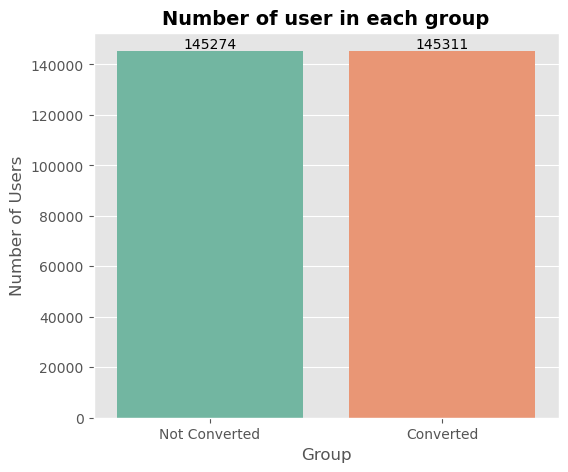

In [38]:
plt.figure(figsize = (6,5))

ax = sns.countplot(
    data = df_clean,
    x = "group",
    hue = 'group',
    palette = 'Set2',
    legend = False
)

plt.title("Number of user in each group", fontsize =14, fontweight='bold')
plt.xlabel("Group")
plt.ylabel("Number of Users")

plt.xticks([0,1],["Not Converted","Converted"])
#add data labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Insight

- Approximately **12%** of users completed the desired action (conversion).
- Around **88%** of users did not convert.
- This overall conversion rate serves as the baseline performance of the experiment.
- The next step is to compare the conversion rates of the Control and Treatment groups to determine whether the new landing page performed better.

# Landing Page Distribution
Business Question

How many users saw the old landing page and how many saw the new landing page?

This helps us verify that users were distributed fairly between the two landing pages.

## Count the Landing Pages

In [39]:
landing_page_count = df_clean['landing_page'].value_counts()
landing_page_count

landing_page
new_page    145311
old_page    145274
Name: count, dtype: int64

# Display Percentage Distribution

In [40]:
landing_page_percent = df_clean['landing_page'].value_counts(normalize = True) * 100
print(landing_page_percent.round(2))

landing_page
new_page    50.01
old_page    49.99
Name: proportion, dtype: float64


# Visualize with Seaborn

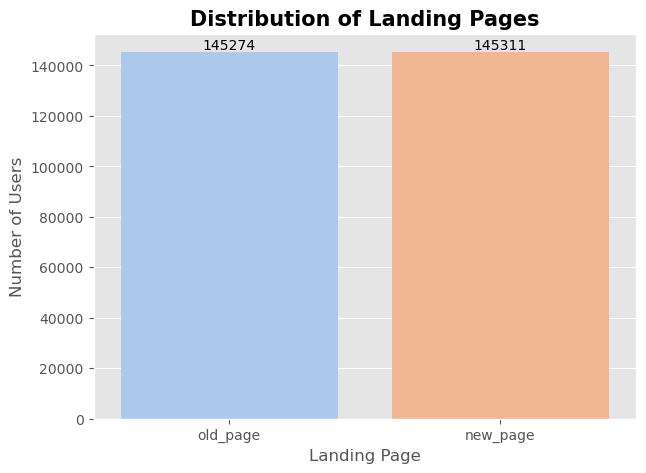

In [41]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data = df_clean,
    x = "landing_page",
    hue = "landing_page",
palette = 'pastel',
    legend = False
)

plt.title("Distribution of Landing Pages", fontsize=15, fontweight='bold')
plt.xlabel("Landing Page")
plt.ylabel("Number of Users")

#Add label
for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Insight

- The experiment includes two landing pages: **old_page** and **new_page**.
- The number of users assigned to each landing page is nearly equal.
- This indicates that traffic was distributed evenly between both versions.
- A balanced distribution ensures a fair comparison during the A/B test.

# Conversion Rate by Group (Control vs Treatment)

In [42]:
group_conversion = df_clean.groupby('group')['converted'].mean()
group_conversion

group
control      0.120386
treatment    0.118807
Name: converted, dtype: float64

In [43]:
group_conversion = group_conversion * 100
print(group_conversion)

group
control      12.038630
treatment    11.880725
Name: converted, dtype: float64


# Convert to DataFrame

In [44]:
group_conversion_df = group_conversion.reset_index(name='conversion_rate')

group_conversion_df

,group,conversion_rate
0,control,12.038630
1,treatment,11.880725


In [45]:
type(group_conversion)

pandas.core.series.Series

In [46]:
group_conversion_df = (
    df_clean.groupby('group')['converted']
    .mean()
    .mul(100)
    .reset_index(name='conversion_rate')
)

group_conversion_df

,group,conversion_rate
0,control,12.038630
1,treatment,11.880725


# Create Bar Chart

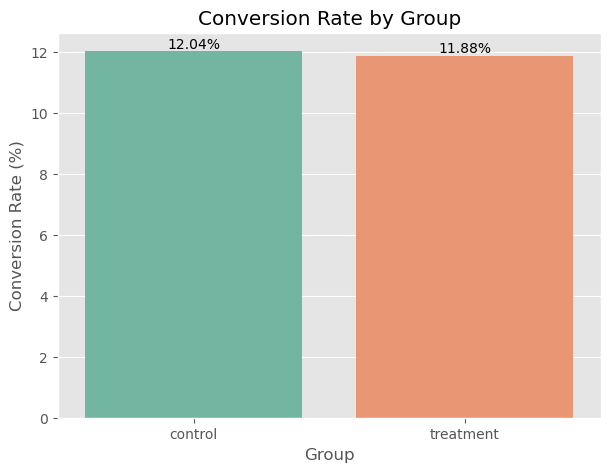

In [47]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=group_conversion_df,
    x='group',
    y='conversion_rate',
    hue='group',
    palette='Set2',
    legend=False
)

plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

# Country-wise User Distribution

In [48]:
country_count = df_clean['country'].value_counts()
country_count

country
US    203620
UK     72466
CA     14499
Name: count, dtype: int64

# Convert to DataFrame

In [49]:
country_df = country_count.reset_index()
country_df.columns = ['Country','Number of Users']
country_df

,Country,Number of Users
0,US,203620
1,UK,72466
2,CA,14499


# Create a Bar Chart

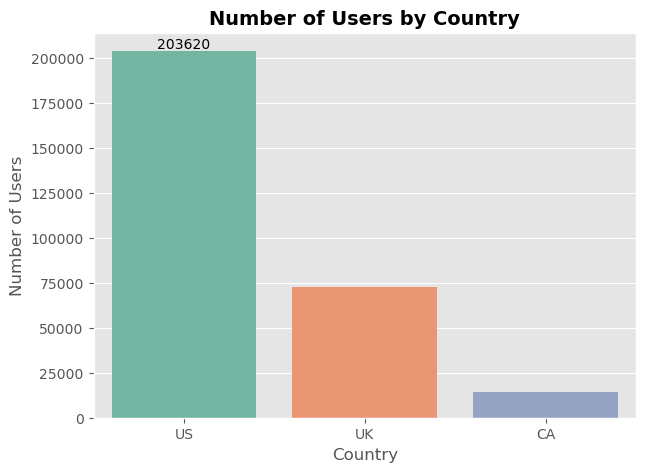

In [50]:
plt.figure(figsize=(7,5))
ax = sns.barplot(
    data = country_df,
    x = "Country",
    y = "Number of Users",
    hue = "Country",
    palette = 'Set2',
    label = False
)

plt.title("Number of Users by Country", fontsize=14, fontweight='bold')
plt.xlabel("Country")
plt.ylabel("Number of Users")

for container in ax.containers:
    ax.bar_label(container)

    plt.show()

### Insight

- The United States (US) has the highest number of users participating in the experiment.
- The United Kingdom (UK) has the second-largest user base.
- Canada (CA) contributes the smallest number of users.
- This indicates that the experiment is heavily influenced by users from the US.

# Conversion Rate by Country

# Business Question

Which country has the highest conversion rate?

This analysis helps answer questions such as:

Which country's users convert the most?
Is user behavior different across countries?
Should the company focus its marketing efforts on a particular country?

In [51]:
country_conversion = (df_clean
    .groupby('country')['converted']
    .mean().mul(100)
    .reset_index(name = 'conversion_rate'))
country_conversion

,country,conversion_rate
0,CA,11.531830
1,UK,12.059449
2,US,11.954621


# Create the Bar Chart

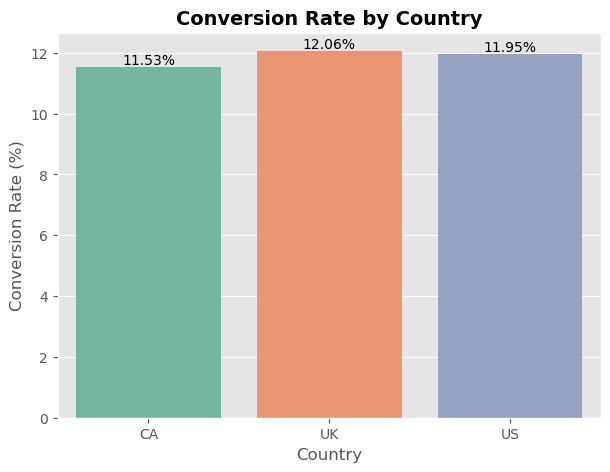

In [52]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=country_conversion,
    x='country',
    y='conversion_rate',
    hue='country',
    palette='Set2',
    legend=False
)

plt.title("Conversion Rate by Country", fontsize=14, fontweight='bold')
plt.xlabel("Country")
plt.ylabel("Conversion Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

# Best-Performing Country

In [53]:
country_conversion.sort_values(
    by='conversion_rate',
    ascending = False
)

,country,conversion_rate
1,UK,12.059449
2,US,11.954621
0,CA,11.531830


### Insight

- The conversion rates across countries are very similar.
- The UK has the highest conversion rate, followed closely by the US.
- Canada has the lowest conversion rate.
- The differences are relatively small, suggesting that user behavior is fairly consistent across countries.

# Conversion Rate by Group and Country

In [55]:
country_group_conversion = (
    df_clean.groupby(['country','group'])['converted']
        .mean()
        .mul(100)
        .reset_index(name='conversion_rate')
)
country_group_conversion

,country,group,conversion_rate
0,CA,control,11.878300
1,CA,treatment,11.190248
2,UK,control,12.002200
3,UK,treatment,12.117100
4,US,control,12.062999
5,US,treatment,11.846444


# Visualization

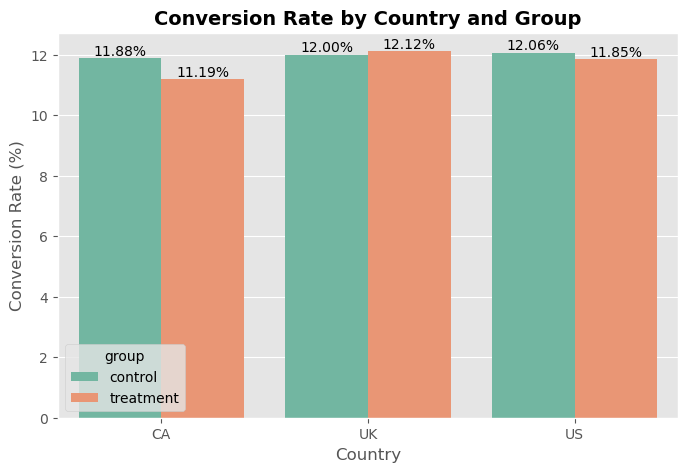

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=country_group_conversion,
    x='country',
    y='conversion_rate',
    hue='group',
    palette='Set2'
)

plt.title("Conversion Rate by Country and Group",
          fontsize=14,
          fontweight='bold')

plt.xlabel("Country")
plt.ylabel("Conversion Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

## Insight

- Conversion rates were compared across both countries and experimental groups.
- This analysis helps determine whether the new landing page performs consistently across different geographic regions.
- Any observed differences should be validated using statistical hypothesis testing before making business decisions.

# Hypothesis Testing

The goal of this A/B test is to determine whether the new landing page increases the conversion rate.

### Null Hypothesis (H₀)

The new landing page has no effect on the conversion rate.

H₀: p_new = p_old

### Alternative Hypothesis (H₁)

The new landing page has a higher conversion rate than the old landing page.

H₁: p_new > p_old

### Significance Level

The significance level is set to **0.05 (5%)**.

If the p-value is less than 0.05, we reject the null hypothesis.

Otherwise, we fail to reject the null hypothesis.

In [58]:
from statsmodels.stats.proportion import proportions_ztest

# Count the Number of Conversions

In [60]:
conversion_count = df_clean.groupby('group')['converted'].sum()

conversion_count

group
control      17489
treatment    17264
Name: converted, dtype: int64

# Count Total Users

In [61]:
n_users = df_clean.groupby('group')['converted'].count()
n_users

group
control      145274
treatment    145311
Name: converted, dtype: int64

# Perform the Z-Test

In [63]:
z_stat, p_value = proportions_ztest(
    count = conversion_count,
    nobs = n_users,
    alternative = 'larger'
)

print("Z-statistic :", z_stat)
print("P-value :", p_value)

Z-statistic : 1.3116075339133115
P-value : 0.09482629485940902


## Hypothesis Test Result

- Significance Level (α) = 0.05
- Z-statistic = 1.3116
- P-value = 0.0948

### Decision

Since the p-value (0.0948) is greater than the significance level (0.05), we fail to reject the null hypothesis.

### Conclusion

There is not enough statistical evidence to conclude that the new landing page has a higher conversion rate than the old landing page.

The observed improvement is not statistically significant and may have occurred due to random chance.

## Business Recommendation

Based on the A/B test results, the company should not replace the existing landing page with the new landing page at this time.

Although the treatment group showed a slightly higher conversion rate, the difference was not statistically significant at the 5% significance level.

The company may consider:
- Running the experiment for a longer period.
- Increasing the sample size.
- Testing a redesigned landing page with more substantial changes.

## Final Conclusion

## Objective

The objective of this A/B test was to determine whether the new landing page (Treatment Group) achieved a higher conversion rate than the existing landing page (Control Group).

## Key Findings

- The dataset was cleaned and validated before analysis.
- The user distribution between the Control and Treatment groups was balanced.
- The overall conversion rates of both groups were very similar.
- Country-wise analysis showed only minor variations in conversion rates.
- A Two-Proportion Z-Test was conducted to compare the conversion rates statistically.

## Statistical Result

- Z-statistic = 1.3116
- P-value = 0.0948
- Significance Level (α) = 0.05

Since the p-value (0.0948) is greater than the significance level (0.05), we fail to reject the null hypothesis.

## Conclusion

Based on the statistical analysis, there is insufficient evidence to conclude that the new landing page performs better than the existing landing page.

Although the Treatment group achieved a slightly higher conversion rate, the improvement is not statistically significant and may have occurred due to random variation.

# Business Recommendation

Based on the results of this A/B test:

- Continue using the existing landing page.
- Do not deploy the new landing page based solely on this experiment.
- Run the experiment for a longer duration to collect more data.
- Consider testing a redesigned landing page with more impactful changes.
- Perform additional A/B tests by segmenting users based on device type, traffic source, or geography to identify specific user groups that may respond differently.

 # Project Limitations

- The analysis focused only on conversion rate as the success metric.
- Other business metrics such as revenue, bounce rate, and session duration were not available.
- User behavior was analyzed only across three countries.
- External factors such as seasonality, marketing campaigns, or user demographics were not included in the analysis.

# Future Improvements

- Increase the experiment duration to collect additional observations.
- Include user demographics such as age and gender.
- Analyze conversions by device type (mobile vs desktop).
- Perform segmented A/B testing based on traffic source.
- Evaluate additional business metrics such as revenue per visitor and customer lifetime value.

# Skills Demonstrated

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Data Visualization
- Hypothesis Testing
- Two-Proportion Z-Test
- Statistical Analysis
- Business Analytics